In [108]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [109]:
walmart_data = pd.read_csv('data/walmart-sales-dataset-of-45stores.csv')

In [110]:
walmart_data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [111]:
walmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [112]:
## Change the 'Date' column to datetime format
walmart_data['Date'] = pd.to_datetime(walmart_data['Date'], format='%d-%m-%Y') 

<Axes: xlabel='Date'>

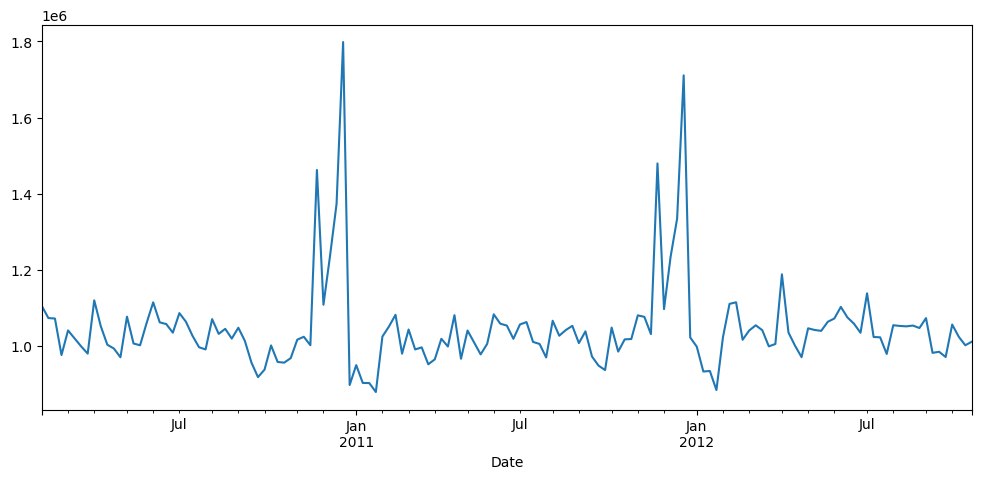

In [113]:
## Average weekly sales over time 
walmart_data.groupby('Date')['Weekly_Sales'].mean().plot(figsize=(12,5))

<Axes: >

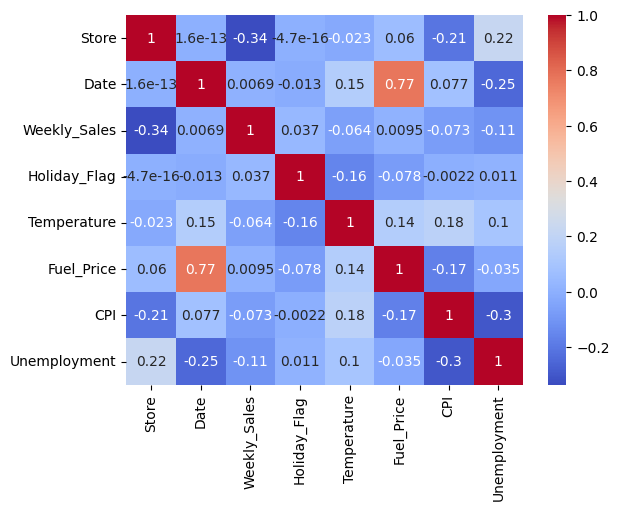

In [114]:
## Correlations
import seaborn as sns
sns.heatmap(walmart_data.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='Month'>

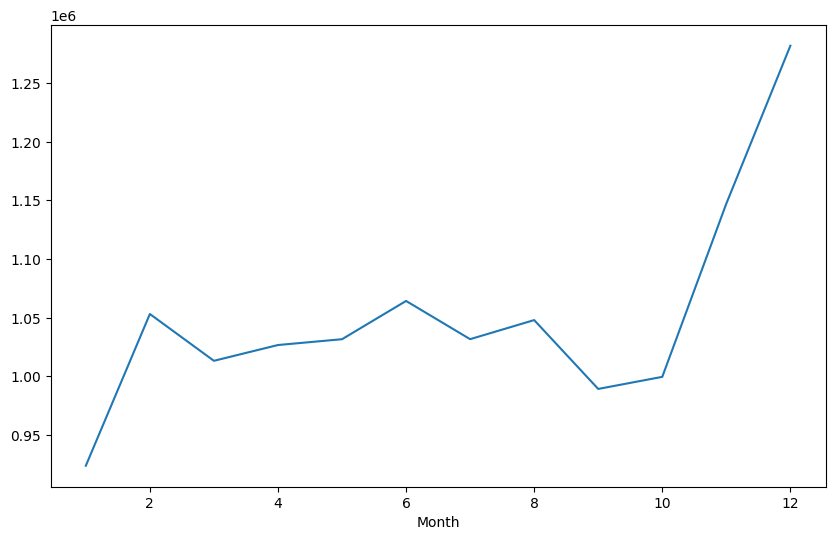

In [115]:
## Per month
walmart_data['Month'] = walmart_data['Date'].dt.month
monthly_sales = walmart_data.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(kind='line', figsize=(10,6))

In [116]:
## Some feature engineering
walmart_data['Year'] = walmart_data['Date'].dt.year
walmart_data['Weekday'] = walmart_data['Date'].dt.weekday

In [117]:
walmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Month         6435 non-null   int32         
 9   Year          6435 non-null   int32         
 10  Weekday       6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


In [ ]:
# Sum across all stores
ts = (walmart_data
      .groupby("Date", as_index=False)["Weekly_Sales"]
      .sum()
      .sort_values("Date")
      .set_index("Date"))

y = ts["Weekly_Sales"]

# Chronological split (e.g., last 20% as test)
test_size = 0.20
split_idx = int(len(y) * (1 - test_size))

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

In [131]:
print(ts.shape)
ts.head()

(143, 1)


,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


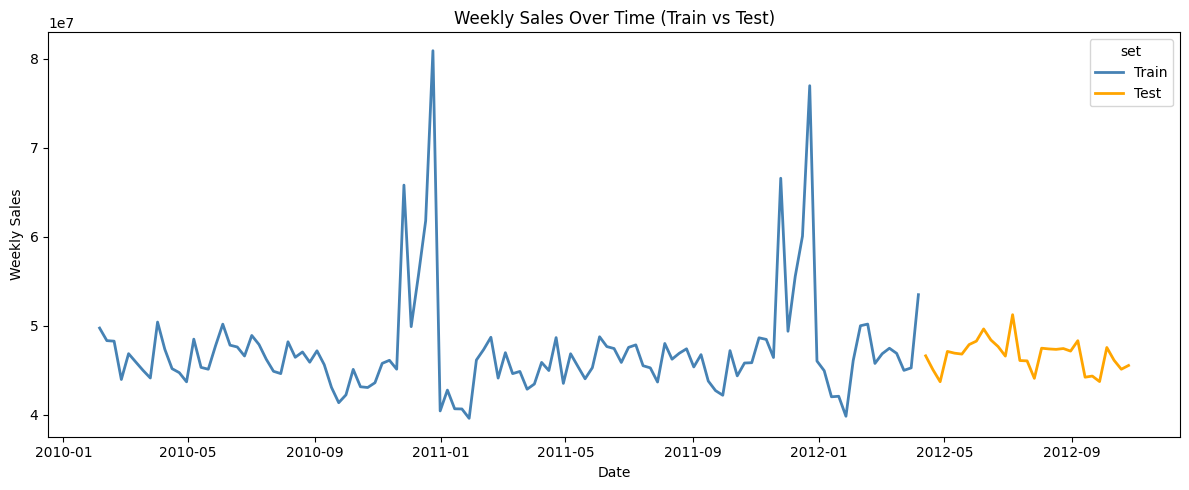

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstruct a plotting DataFrame
plot_df = ts.copy()

# Create train / test labels based on the split indices
plot_df["set"] = "Train"
plot_df.loc[y_test.index, "set"] = "Test"

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=plot_df,
    x="Date",
    y="Weekly_Sales",
    hue="set",
    palette={"Train": "steelblue", "Test": "orange"},
    linewidth=2
)

plt.title("Weekly Sales Over Time (Train vs Test)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

Next, we perform time series prediction using naive and naive seasonal models. The naive model just uses the last available real value as the predicted and the naive seasonal uses the value from the same week in the previous year. These will function as essential baselines to compared our future models to. 

In [121]:
# Naive: predict last observed train value for all test points
season_len = 1
y_pred_naive = y.shift(season_len).loc[y_test.index]
y_pred_naive.name = "Naive"

# Seasonal naive: predict value from same week last year (52 weeks back)
season_len = 52
y_pred_seasonal_naive = y.shift(season_len).loc[y_test.index]
y_pred_seasonal_naive.name = "Seasonal Naive"

# Fill any missing seasonal values
y_pred_seasonal_naive = y_pred_seasonal_naive.fillna(y_pred_naive)


In [ ]:
# Metrics
metrics = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MSE": [
        mean_squared_error(y_test, y_pred_naive),
        mean_squared_error(y_test, y_pred_seasonal_naive)
    ],
    "R2": [
        r2_score(y_test, y_pred_naive),
        r2_score(y_test, y_pred_seasonal_naive)
    ]
})
print(metrics)


            Model           MSE        R2
0           Naive  5.854816e+12 -0.954520
1  Seasonal Naive  2.442706e+12  0.184548


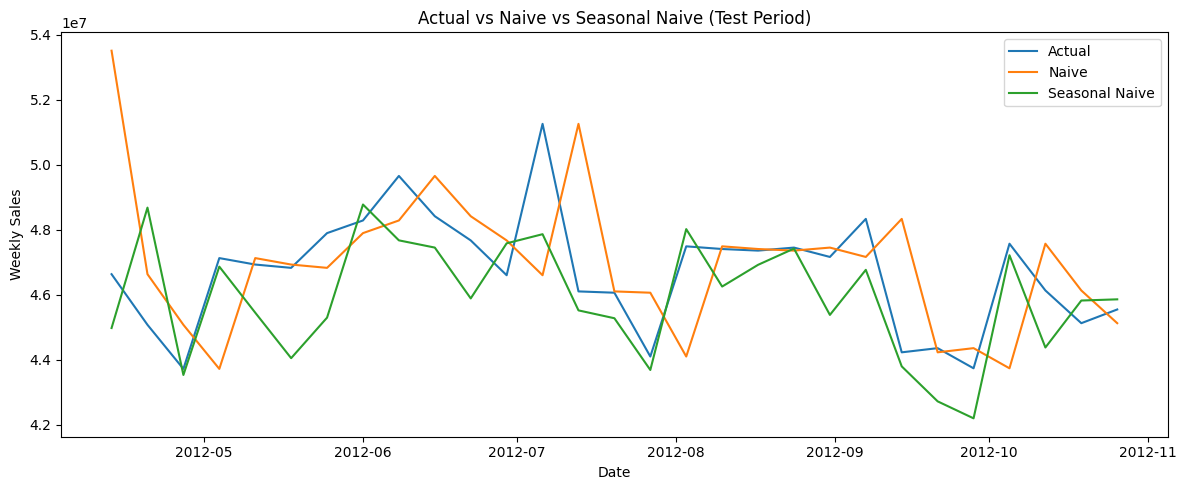

In [ ]:
# Plot actual vs forecasts
plot_df = pd.DataFrame({
    "Actual": y_test,
    "Naive": y_pred_naive,
    "Seasonal Naive": y_pred_seasonal_naive
}).reset_index().rename(columns={"Date": "Date"})

plt.figure(figsize=(12, 5))
sns.lineplot(data=plot_df, x="Date", y="Actual", label="Actual")
sns.lineplot(data=plot_df, x="Date", y="Naive", label="Naive")
sns.lineplot(data=plot_df, x="Date", y="Seasonal Naive", label="Seasonal Naive")
plt.title("Actual vs Naive vs Seasonal Naive (Test Period)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Framewo

Best ARIMA order by AIC: (2, 1, 2)  |  AIC: 3859.87
ARIMA(2, 1, 2)  MSE: 5,814,631,006,077.59
ARIMA(2, 1, 2)  R² : -0.9411


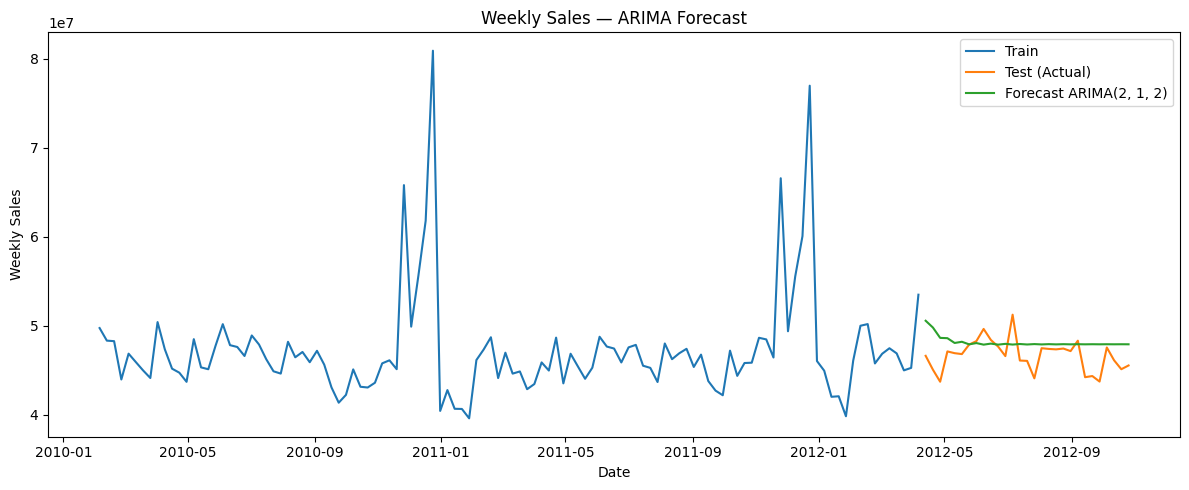

In [129]:
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

best_aic = np.inf
best_order = None
best_model = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(y_train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted
            except Exception:
                continue

print(f"Best ARIMA order by AIC: {best_order}  |  AIC: {best_aic:.2f}")

# Forecast over test
n_test = len(y_test)
forecast = best_model.forecast(steps=n_test)
forecast.index = y_test.index  # align

# Metrics
mse = mean_squared_error(y_test, forecast)
r2 = r2_score(y_test, forecast)

print(f"ARIMA{best_order}  MSE: {mse:,.2f}")
print(f"ARIMA{best_order}  R² : {r2:.4f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)")
plt.plot(forecast.index, forecast, label=f"Forecast ARIMA{best_order}")
plt.title("Weekly Sales — ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure Date is datetime
walmart_data = walmart_data.copy()
walmart_data["Date"] = pd.to_datetime(walmart_data["Date"])

# Roll up to ONE row per week
walmart_weekly = (
    walmart_data
    .groupby("Date", as_index=False)
    .agg(
        Weekly_Sales=("Weekly_Sales", "sum"),
        Holiday_Flag=("Holiday_Flag", "max"),   
        Temperature=("Temperature", "mean"),
        Fuel_Price=("Fuel_Price", "mean"),
        CPI=("CPI", "mean"),
        Unemployment=("Unemployment", "mean"),
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

print(walmart_weekly.shape)
walmart_weekly.head()






(143, 7)


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [132]:
import numpy as np
import pandas as pd

def make_ts_features_weekly(df, date_col="Date", target_col="Weekly_Sales"):
    """
    Feature engineering for a *single* weekly time series (one row per week).
    Adds:
      - calendar features (year, month, weekofyear)
      - lag features (1,2,4,8,13,26,52 weeks)
      - rolling mean/std on shifted target (prevents leakage)
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    # calendar features
    iso = df[date_col].dt.isocalendar()
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["weekofyear"] = iso.week.astype(int)

    # lag features
    lags = [1, 2, 4, 8, 13, 26, 52]
    for lag in lags:
        df[f"lag_{lag}"] = df[target_col].shift(lag)

    # rolling stats on shifted target (no leakage)
    y_shift = df[target_col].shift(1)
    windows = [4, 8, 12, 26, 52]
    for w in windows:
        df[f"roll_mean_{w}"] = y_shift.rolling(window=w, min_periods=w).mean()
        df[f"roll_std_{w}"]  = y_shift.rolling(window=w, min_periods=w).std()

    return df


In [133]:
walmart_weekly_feat = make_ts_features_weekly(
    walmart_weekly,
    date_col="Date",
    target_col="Weekly_Sales"
)

walmart_weekly_feat.head(10)

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,year,month,weekofyear,...,roll_mean_4,roll_std_4,roll_mean_8,roll_std_8,roll_mean_12,roll_std_12,roll_mean_26,roll_std_26,roll_mean_52,roll_std_52
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311,2010,2,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311,2010,2,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311,2010,2,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311,2010,2,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311,2010,3,9,...,4.758325e+07,2.504187e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2010-03-12,45925396.51,0,47.432444,2.774422,167.985598,8.619311,2010,3,10,...,4.686343e+07,2.045230e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2010-03-19,44988974.64,0,49.954222,2.817089,167.930427,8.619311,2010,3,11,...,4.626061e+07,1.807831e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2010-03-26,44133961.05,0,48.473556,2.824111,167.859731,8.619311,2010,3,12,...,4.543860e+07,1.245423e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2010-04-02,50423831.26,0,53.120889,2.827333,167.789036,8.497711,2010,4,13,...,4.547995e+07,1.181453e+06,4.653160e+07,2.133008e+06,NaN,NaN,NaN,NaN,NaN,NaN
9,2010-04-09,47365290.44,0,58.420667,2.853089,167.718340,8.497711,2010,4,14,...,4.636804e+07,2.801089e+06,4.661573e+07,2.285920e+06,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Target
y = walmart_weekly_feat["Weekly_Sales"]

# Feature set
feature_cols = (
    ["year", "month", "weekofyear"]
    + [c for c in walmart_weekly_feat.columns if c.startswith("lag_")]
    + [c for c in walmart_weekly_feat.columns if c.startswith("roll_")]
    + [c for c in ["Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
       if c in walmart_weekly_feat.columns]
)

# Drop rows with missing lags/rollings
df_model = walmart_weekly_feat.dropna(subset=feature_cols + ["Weekly_Sales"]).copy()

X = df_model[feature_cols]
y = df_model["Weekly_Sales"]

# Chronological split (last 20%)
test_size = 0.20
split_idx = int(len(y) * (1 - test_size))

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = df_model["Date"].iloc[split_idx:]

print("Train rows:", len(X_train))
print("Test rows :", len(X_test))

Train rows: 72
Test rows : 19


In [135]:
## XGBoost model
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=123
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)


In [136]:
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"XGBoost Weekly Forecast")
print(f"MSE: {mse:,.2f}")
print(f"R² : {r2:.4f}")


XGBoost Weekly Forecast
MSE: 4,501,619,834,948.08
R² : -0.4546


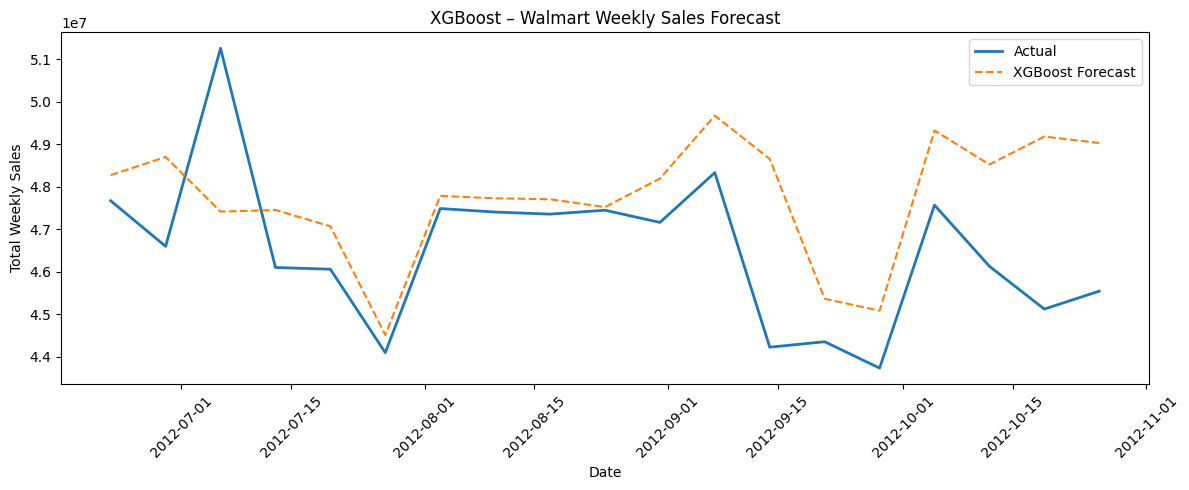

In [137]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test, label="Actual", linewidth=2)
plt.plot(dates_test, y_pred, label="XGBoost Forecast", linestyle="--")

plt.title("XGBoost – Walmart Weekly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
